In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [5]:
# Khám phá dữ liệu
salary_data = pd.read_csv("salary_synthetic.csv")

salary_data.shape

(2000, 15)

In [6]:
salary_data.head()

,age,gender,education,experience_years,role_seniority,company_size,location_tier,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_date,recent_note
0,33,Male,M.Sc,6.0,Senior,Enterprise,Tier-2,1.0,2.0,1,0.0,145185,57.0,2024-11-15,Worked on microservices deployment
1,29,Male,M.Sc,9.0,Junior,Enterprise,Remote,5.0,0.0,1,0.0,121262,50.0,2024-03-08,Built ML pipeline for preprocessing
2,34,Male,B.Sc+Cert,NaN,Lead,Enterprise,Remote,5.0,1.0,1,5.0,184875,50.0,2024-09-01,Experience in data cleaning and ETL
3,39,Male,B.Sc,16.0,Mid,Enterprise,Tier-1,5.0,0.0,1,3.0,180105,59.0,2024-01-26,Contributed to open-source NLP repo
4,29,Female,B.Sc,8.0,Junior,SME,Tier-1,5.0,2.0,0,7.0,114750,NaN,2023-12-08,Built ML pipeline for preprocessing


Tập dữ liệu chứa thông tin về nhân viên, bao gồm employees, including demographic characteristics, education, work experience, skills, certifications, working conditions, promotion history, and salary. Biến mục tiêu được sử dụng cho hồi quy là salary_bdt.

In [7]:
salary_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                2000 non-null   int64  
 1   gender                             2000 non-null   str    
 2   education                          1900 non-null   str    
 3   experience_years                   1840 non-null   float64
 4   role_seniority                     2000 non-null   str    
 5   company_size                       2000 non-null   str    
 6   location_tier                      2000 non-null   str    
 7   skills_count                       1800 non-null   float64
 8   certifications                     1920 non-null   float64
 9   worked_remote                      2000 non-null   int64  
 10  last_promotion_years_ago           1880 non-null   float64
 11  salary_bdt                         2000 non-null   int64  
 12  rec

In [8]:
salary_data.isnull().sum()

age                                    0
gender                                 0
education                            100
experience_years                     160
role_seniority                         0
company_size                           0
location_tier                          0
skills_count                         200
certifications                        80
worked_remote                          0
last_promotion_years_ago             120
salary_bdt                             0
recent_project_description_length    240
survey_date                            0
recent_note                          300
dtype: int64

Kiểm tra tương quan với biến mục tiêu trước khi xử lý missing. Nếu Biến tương quan cao chứa missing thì xử lý missing value.

In [ ]:
#Xét các biến có định dạng số giống biến target
numeric_data = salary_data.select_dtypes(include=np.number)

numeric_data.columns

Index(['age', 'experience_years', 'skills_count', 'certifications',
       'worked_remote', 'last_promotion_years_ago', 'salary_bdt',
       'recent_project_description_length'],
      dtype='str')

Tương quan đo lường độ mạnh và hướng của mối quan hệ tuyến tính giữa hai biến số.

Hệ số tương quan có giá trị nằm trong khoảng từ -1 đến 1:

Giá trị gần bằng 1 thể hiện mối quan hệ tuyến tính đồng biến (tương quan thuận) mạnh.

Giá trị gần bằng -1 thể hiện mối quan hệ tuyến tính nghịch biến (tương quan nghịch) mạnh.

Giá trị gần bằng 0 thể hiện mối quan hệ tuyến tính yếu.

In [10]:
corr = numeric_data.corr()

corr

,age,experience_years,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length
age,1.000000,0.930218,-0.015152,-0.030424,-0.031376,-0.016256,0.765101,-0.001742
experience_years,0.930218,1.000000,-0.032282,-0.035930,-0.036534,-0.021014,0.826231,-0.005472
skills_count,-0.015152,-0.032282,1.000000,-0.015025,-0.011781,-0.003384,0.037809,-0.003638
certifications,-0.030424,-0.035930,-0.015025,1.000000,0.044998,0.003233,0.015044,0.026025
worked_remote,-0.031376,-0.036534,-0.011781,0.044998,1.000000,-0.024372,0.011874,0.008350
last_promotion_years_ago,-0.016256,-0.021014,-0.003384,0.003233,-0.024372,1.000000,-0.015071,-0.031173
salary_bdt,0.765101,0.826231,0.037809,0.015044,0.011874,-0.015071,1.000000,-0.015976
recent_project_description_length,-0.001742,-0.005472,-0.003638,0.026025,0.008350,-0.031173,-0.015976,1.000000


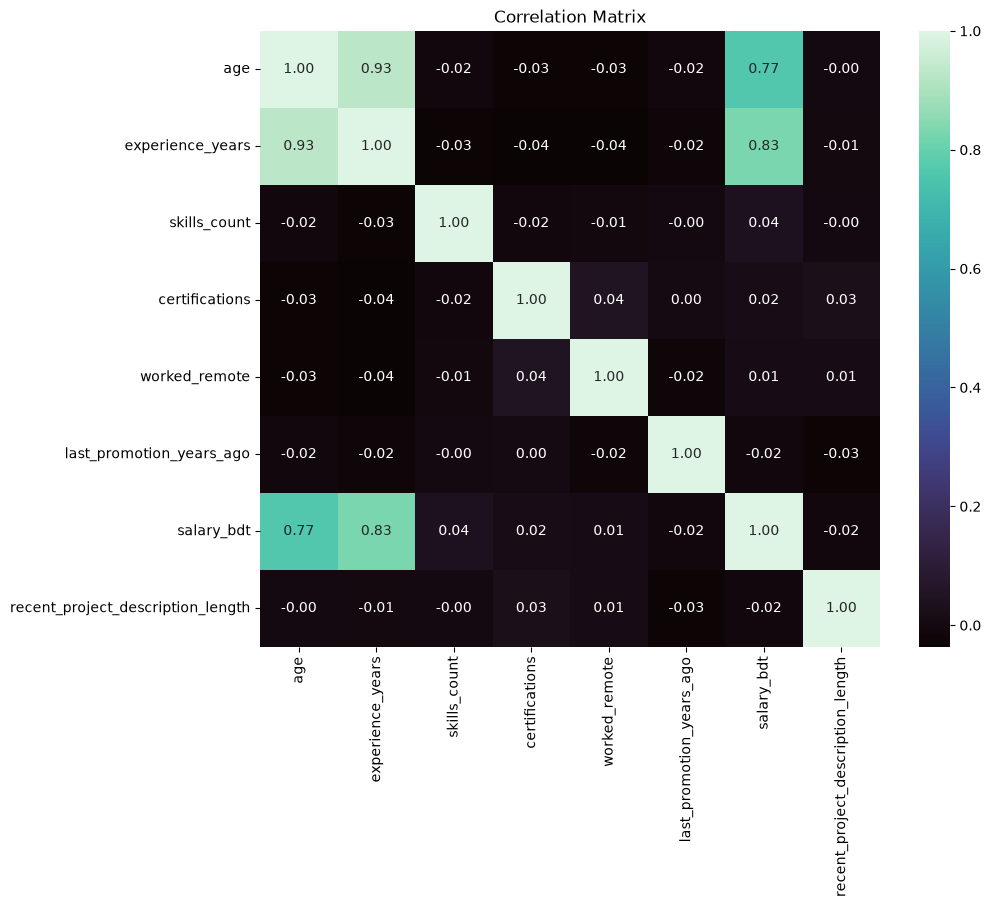

In [11]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='mako'
)

plt.title('Correlation Matrix')
plt.show()

-> Biến có tương quan lớn với salary_bdt là experience_years, tiếp theo tiến hành tiến xử lý 160 giá trị thiếu 

In [ ]:
# Chọn một biến độc lập để dự đoán biến phụ thuộc
selected_feature = 'experience_years'

X = salary_data[[selected_feature]]
y = salary_data['salary_bdt']

In [ ]:
# Loại các dòng missing trong dữ liệu
model_data = salary_data[[selected_feature, 'salary_bdt']].dropna()

model_data.shape

(1840, 2)

In [14]:
X = model_data[[selected_feature]]
y = model_data['salary_bdt']

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1840, 1)
y shape: (1840,)


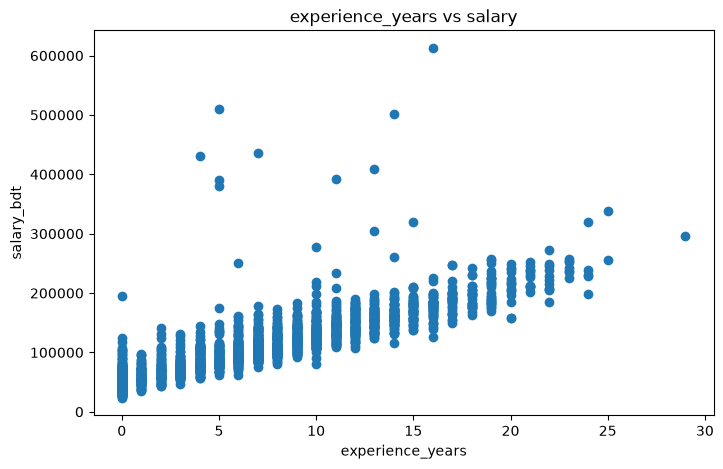

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[selected_feature],
    y
)

plt.xlabel(selected_feature)
plt.ylabel('salary_bdt')
plt.title(f'{selected_feature} vs salary')

plt.show()

In [18]:
# Chia train và test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=4
)

In [19]:
slr = LinearRegression()
slr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7916.17]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['experience_years']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.547e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Hệ số chặn 𝛽 đại diện cho mức lương dự đoán khi biến độc lập được chọn có giá trị bằng 0.Việc diễn giải ý nghĩa thực tế của nó phụ thuộc vào việc giá trị bằng 0 của đặc trưng được chọn có mang ý nghĩa thực tiễn trong tập dữ liệu hay không.

In [20]:
# LinearRegression y=αx+β
# 𝛽
slr.intercept_

np.float64(55467.0944840571)

In [21]:
## 𝛼
slr.coef_

array([7916.17122136])

In [22]:
print("Intercept (β0):", slr.intercept_)
print("Coefficient (β1):", slr.coef_[0])

print(
    f"Regression equation: "
    f"salary_bdt = {slr.intercept_:.2f} + "
    f"{slr.coef_[0]:.2f} × {selected_feature}"
)

Intercept (β0): 55467.0944840571
Coefficient (β1): 7916.17122136164
Regression equation: salary_bdt = 55467.09 + 7916.17 × experience_years


In [23]:
# Model evaluation
y_pred_train = slr.predict(X_train)
y_pred_test = slr.predict(X_test)

In [24]:
prediction_result = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred_test
})

prediction_result.head(10)

,Actual Salary,Predicted Salary
0,211922,197958.176469
1,126360,118796.464255
2,62122,55467.094484
3,87071,63383.265705
4,149851,142544.977919
5,150363,150461.149140
6,91963,110880.293034
7,156630,174209.662804
8,169169,150461.149140
9,168780,158377.320362


Mô hình được đánh giá bằng cách sử dụng: 
- R² (Hệ số tương quan bình phương) 
- MAE (Sai ​​số tuyệt đối trung bình) 
- MSE (Sai ​​số bình phương trung bình) Các chỉ số được tính toán cho cả tập dữ liệu huấn luyện và kiểm tra.

In [25]:
print("Training Evaluation")
print("-------------------")

print("R²:", metrics.r2_score(y_train, y_pred_train))
print("MAE:", metrics.mean_absolute_error(y_train, y_pred_train))
print("MSE:", metrics.mean_squared_error(y_train, y_pred_train))

Training Evaluation
-------------------
R²: 0.7177649073535215
MAE: 16321.808906796909
MSE: 761111349.8116037


In [26]:
print("Testing Evaluation")
print("------------------")

print("R²:", metrics.r2_score(y_test, y_pred_test))
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_test))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_test))

Testing Evaluation
------------------
R²: 0.6228721756582922
MAE: 18626.03542525135
MSE: 1443178137.112926


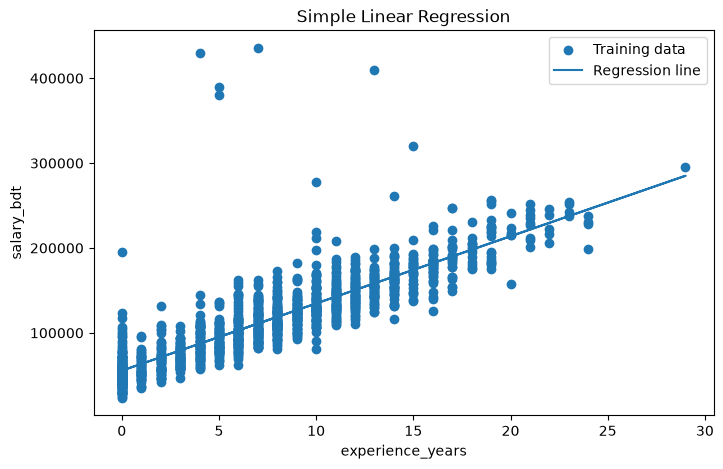

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_train[selected_feature],
    y_train,
    label='Training data'
)

plt.plot(
    X_train[selected_feature],
    y_pred_train,
    label='Regression line'
)

plt.xlabel(selected_feature)
plt.ylabel('salary_bdt')
plt.title('Simple Linear Regression')
plt.legend()

plt.show()

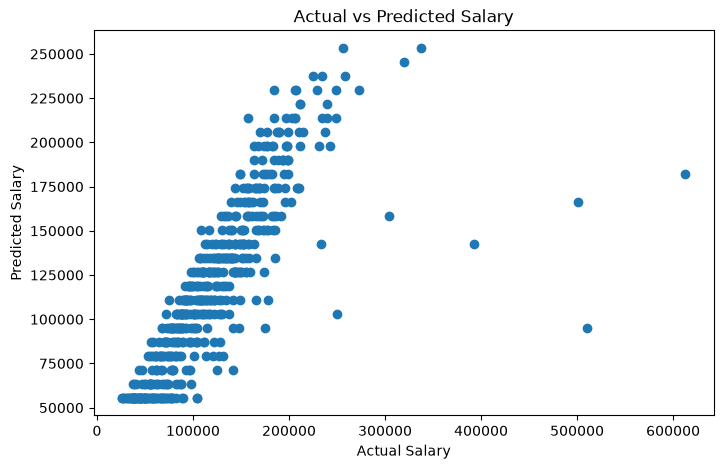

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_test
)

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')

plt.show()